# 08. Сравнение ОФЗ-ПД и ОФЗ-ПК

Ноутбук соответствует четвёртой странице дашборда: сравнение поведения облигаций с постоянным и переменным купоном.

Используются только дневные данные с присоединённой ключевой ставкой.


## 1. Импорт и загрузка данных

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
SUMMARY_DIR = DATA_DIR / "summary"
FIGURES_DIR = PROJECT_ROOT / "report" / "figures"

for path in [SUMMARY_DIR, FIGURES_DIR]:
    path.mkdir(parents=True, exist_ok=True)

In [2]:
FIXED_PATH = PROCESSED_DIR / "fixed_datalens" / "ofz_fixed_with_key_rate_for_datalens.csv"
FLOATING_PATH = PROCESSED_DIR / "floating_datalens" / "ofz_floating_with_key_rate_for_datalens.csv"

for path in [FIXED_PATH, FLOATING_PATH]:
    if not path.exists():
        raise FileNotFoundError(f"Файл не найден: {path.resolve()}. Сначала запустите 04_prepare_datalens_datasets.ipynb")

fixed = pd.read_csv(FIXED_PATH)
floating = pd.read_csv(FLOATING_PATH)

fixed["TRADEDATE"] = pd.to_datetime(fixed["TRADEDATE"], errors="coerce")
floating["TRADEDATE"] = pd.to_datetime(floating["TRADEDATE"], errors="coerce")

fixed["RATE_FOR_ANALYSIS"] = fixed["YIELD_FOR_ANALYSIS"]
floating["RATE_FOR_ANALYSIS"] = floating["FLOATING_COUPON_RATE_EST"]

df = pd.concat([fixed, floating], ignore_index=True, sort=False)

print("Combined shape:", df.shape)
display(df.head())

Combined shape: (15522, 17)


,TRADEDATE,SECID,SHORTNAME,COUPON_TYPE,PLOT_GROUP,PRICE_FOR_ANALYSIS,YIELD_FOR_ANALYSIS,RATE_FOR_ANALYSIS,YEARS_TO_MATURITY,DURATION,VALUE,key_rate,YIELD_KEY_RATE_SPREAD,RATE_KEY_RATE_SPREAD,ACCINT,FLOATING_COUPON_RATE_EST,FLOATING_COUPON_KEY_RATE_SPREAD
0,2016-05-04,SU26207RMFS9,ОФЗ 26207,fixed,long,95.5773,8.99,8.99,10.751540,2610.0,7.549269e+08,11.0,-2.01,-2.01,NaN,NaN,NaN
1,2016-05-05,SU26207RMFS9,ОФЗ 26207,fixed,long,95.6335,8.98,8.98,10.748802,2610.0,1.133353e+08,11.0,-2.02,-2.02,NaN,NaN,NaN
2,2016-05-06,SU26207RMFS9,ОФЗ 26207,fixed,long,95.7770,8.95,8.95,10.746064,2610.0,2.091805e+08,11.0,-2.05,-2.05,NaN,NaN,NaN
3,2016-05-10,SU26207RMFS9,ОФЗ 26207,fixed,long,95.7496,8.96,8.96,10.735113,2606.0,2.660816e+07,11.0,-2.04,-2.04,NaN,NaN,NaN
4,2016-05-11,SU26207RMFS9,ОФЗ 26207,fixed,long,96.3739,8.86,8.86,10.732375,2610.0,5.351472e+08,11.0,-2.14,-2.14,NaN,NaN,NaN


## 2. Дневное сравнение цены и процентного показателя

In [3]:
daily_compare = (
    df
    .groupby(["TRADEDATE", "COUPON_TYPE"], as_index=False)
    .agg(
        avg_price=("PRICE_FOR_ANALYSIS", "mean"),
        median_price=("PRICE_FOR_ANALYSIS", "median"),
        avg_rate=("RATE_FOR_ANALYSIS", "mean"),
        total_value=("VALUE", "sum"),
        key_rate=("key_rate", "last"),
        n_bonds=("SECID", "nunique"),
    )
    .sort_values(["TRADEDATE", "COUPON_TYPE"])
)

display(daily_compare.head())

,TRADEDATE,COUPON_TYPE,avg_price,median_price,avg_rate,total_value,key_rate,n_bonds
0,2016-05-04,fixed,95.5773,95.5773,8.99,7.549269e+08,11.0,1
1,2016-05-05,fixed,95.6335,95.6335,8.98,1.133353e+08,11.0,1
2,2016-05-06,fixed,95.7770,95.7770,8.95,2.091805e+08,11.0,1
3,2016-05-10,fixed,95.7496,95.7496,8.96,2.660816e+07,11.0,1
4,2016-05-11,fixed,96.3739,96.3739,8.86,5.351472e+08,11.0,1


## 3. Сравнение цены ОФЗ-ПД и ОФЗ-ПК

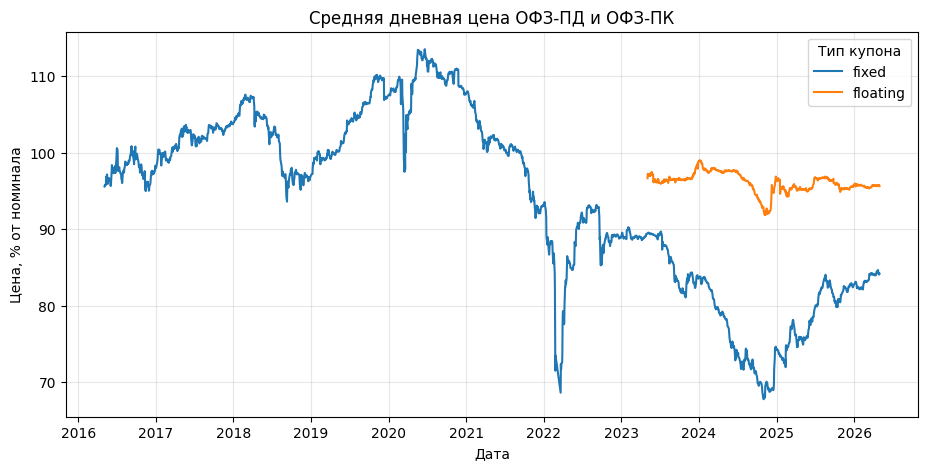

Saved figure: /Users/daniilsestov/Desktop/курсач для гита/ofz_git_notebooks_daily_only/report/figures/page_4_fixed_vs_floating_price_daily.png


In [4]:
fig, ax = plt.subplots(figsize=(11, 5))

for coupon_type, part in daily_compare.groupby("COUPON_TYPE"):
    ax.plot(part["TRADEDATE"], part["avg_price"], label=coupon_type)

ax.set_title("Средняя дневная цена ОФЗ-ПД и ОФЗ-ПК")
ax.set_xlabel("Дата")
ax.set_ylabel("Цена, % от номинала")
ax.grid(True, alpha=0.3)
ax.legend(title="Тип купона")

figure_path = FIGURES_DIR / "page_4_fixed_vs_floating_price_daily.png"
fig.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure:", figure_path.resolve())

## 4. Сравнение доходности/купонной ставки с ключевой ставкой

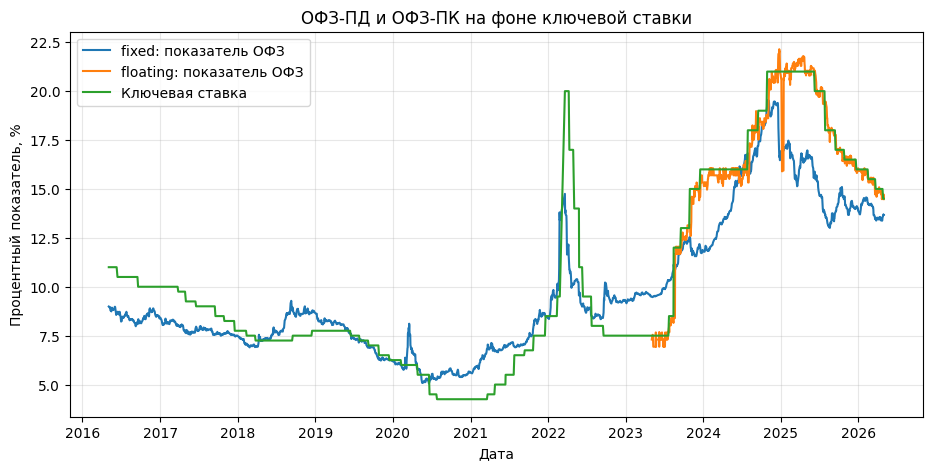

Saved figure: /Users/daniilsestov/Desktop/курсач для гита/ofz_git_notebooks_daily_only/report/figures/page_4_fixed_vs_floating_rate_daily.png


In [5]:
fig, ax = plt.subplots(figsize=(11, 5))

for coupon_type, part in daily_compare.groupby("COUPON_TYPE"):
    ax.plot(part["TRADEDATE"], part["avg_rate"], label=f"{coupon_type}: показатель ОФЗ")

key_rate_daily = daily_compare.drop_duplicates("TRADEDATE").sort_values("TRADEDATE")
ax.plot(key_rate_daily["TRADEDATE"], key_rate_daily["key_rate"], label="Ключевая ставка")

ax.set_title("ОФЗ-ПД и ОФЗ-ПК на фоне ключевой ставки")
ax.set_xlabel("Дата")
ax.set_ylabel("Процентный показатель, %")
ax.grid(True, alpha=0.3)
ax.legend()

figure_path = FIGURES_DIR / "page_4_fixed_vs_floating_rate_daily.png"
fig.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure:", figure_path.resolve())